In [29]:
# Gradient Descent and optimization Techniques

In [30]:
# Gradient Descent and its variants

# Gradient Descent:
    # Optimization algorithm used to minimize the loss function by iteratively adjusting the model's parameters in the direction of the negative gradient

    # Variants of Gradient Descent:
        # Batch Gradient Descent:
            # -USes the entire dataset to compute gradients at each step
            # -pros: Accurate gradients
            # -Cons: Computationally expensive for large datasets, can get stuck in local minima

        # Stochastic Gradient Descent (SGD):
            # -Uses a single random sample to compute gradients at each step
            # -Updates parameters more frequently, which can lead to faster convergence
            # -Pros: Faster updates, can escape local minima
            # -Cons: Noisy updates, can lead to oscillations,higher variance in the loss function, can be less stable

        # Mini-batch Gradient Descent:
            # -Uses a small random subset of the dataset (mini-batch) to compute gradients
            # -Balances the advantages of batch and stochastic gradient descent
            # -Pros: Faster updates than batch gradient descent, less noisy than SGD, can leverage parallel processing
            # -Cons: Still can be computationally expensive for very large datasets, requires tuning of mini-batch size


In [ ]:
# Advanced Optimization Techniques:
# optimization is a critical aspect of training neural networks, and various optimization algorithms have been developed to improve convergence and performance. Some popular optimization techniques include:

# 1. Adagrad:
    # -Adagrad learning rates for each parameter by scaling inversely with the sum of gradients squared
    # -Pros: Adapts learning rates for each parameter, works well for sparse data
    # -Cons: Learning rates can become very small over time, leading to slow convergence

# 2. RMSprop:
    # -Modifies Adagrad by using an exponentially weighted moving average of squared gradients to scale the learning rates
    # -Pros: Addresses Adagrad's aggressive learning rate decay, works well for non-stationary objectives, works well for non-convex optimization problems
    # -Cons: Requires tuning of the decay rate hyperparameter

# 3. Adam (Adaptive Moment Estimation):
    # -Combines the benefits of Adagrad and RMSprop by maintaining both a moving average of the gradients and a moving average of the squared gradients
    # -Pros: Efficient, works well for a wide range of problems, requires less tuning of hyperparameters
    # -Cons: Can be computationally expensive, may not perform well on some problems with sparse gradients


In [32]:
# Importance of Learning rate and choosing the right Optimizer:

# 1.Learning Rate:
    # -Controls the step size at each iteration while moving towards a minimum of the loss function
    # -Too high: Can cause the model to diverge or oscillate around the minimum
    # -Too low: Can lead to slow convergence and getting stuck in local minima
# 2. Choosing the right optimizer:
    # SGD: works well for simple, convex problems and large datasets
    # Adam: often a good default choice for many deep learning problems, especially when dealing with non-convex optimization problems
    # RMSprop: can be effective for recurrent neural networks and non-stationary objectives
    # Adagrad: can be useful for sparse data and when dealing with features of varying importance, but may not be suitable for all problems due to its aggressive learning rate decay



In [33]:
# Exercise: 
# Objective:
    # Implement gradient descent to update model weights and experiment with different optimizers using TensorFlow and/or PyTorch.

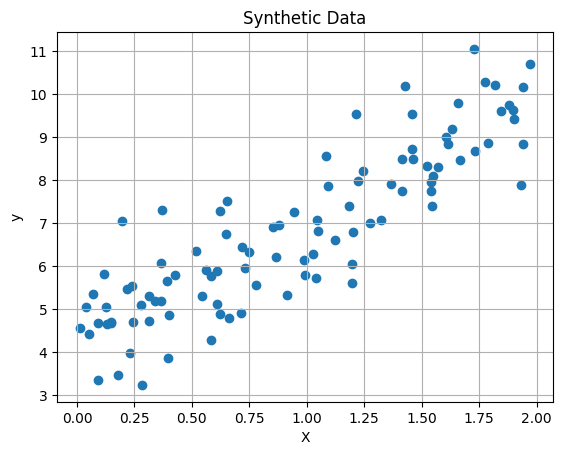

optimized parameters(theta):
  [4.21509616 2.77011339]


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Visualize the data
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.grid()
plt.show()

# initialize parameters
n = 100 # number of samples
theta = np.random.randn(2, 1) # random initialization of parameters
learning_rate = 0.1
iterations = 1000 

# Add bias term to X
X_b = np.c_[np.ones((n, 1)), X] # add bias term to X


# gradient descent loop
for iteration in range(iterations):
    gradients = 2/n * X_b.T.dot(X_b.dot(theta) - y) # compute gradients
    theta -= learning_rate * gradients # update parameters

print(f"optimized parameters(theta):\n  {theta.ravel()}")

In [35]:
# applying tensflow and pytorch optimizers for the same problem
import tensorflow as tf

# prepare data
X_tensor = tf.constant(X, dtype=tf.float32)
y_tensor = tf.constant(y, dtype=tf.float32)

# define model
class LinearModel(tf.Module):
    def __init__(self):
        self.weights = tf.Variable(tf.random.normal([1]))
        self.bias = tf.Variable(tf.random.normal([1]))

    def __call__(self, X):
        return self.weights * X +self.bias
    
# Define loss function
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

# Training with SGD optimizer
model = LinearModel()
optimizer = tf.optimizers.SGD(learning_rate=0.1)

for epoch in range(100):
    with tf.GradientTape() as tape:
        y_pred = model(X_tensor)
        loss = mse_loss(y_tensor, y_pred)
    gradients = tape.gradient(loss, [model.weights, model.bias])
    optimizer.apply_gradients(zip(gradients, [model.weights, model.bias]))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy(): .4f}")


Epoch 0: Loss =  58.5449
Epoch 10: Loss =  0.9723
Epoch 20: Loss =  0.8890
Epoch 30: Loss =  0.8479
Epoch 40: Loss =  0.8273
Epoch 50: Loss =  0.8170
Epoch 60: Loss =  0.8118
Epoch 70: Loss =  0.8092
Epoch 80: Loss =  0.8079
Epoch 90: Loss =  0.8072


In [38]:
# Using pytorch
import torch
import torch.nn as nn
import torch.optim as optim

# prepare the data
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

# define the model
class LinearModelTorch(nn.Module):
    def __init__(self):
        super(LinearModelTorch, self).__init__()
        self.linear = nn.Linear(1, 1) # linear layer with 1 input and 1 output

    def forward(self, X):
        return self.linear(X)
    
model_torch = LinearModelTorch()

# define Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.1)

# train the model
for epoch in range(100):
    optimizer.zero_grad() # zero the parameter gradients
    outputs = model_torch(X_torch) # forward pass
    loss = criterion(outputs, y_torch) # compute loss
    loss.backward() # backward pass
    optimizer.step() # update parameters
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item(): .4f}")


Epoch 0: Loss =  48.4071
Epoch 10: Loss =  24.8241
Epoch 20: Loss =  10.1848
Epoch 30: Loss =  3.2626
Epoch 40: Loss =  1.1807
Epoch 50: Loss =  0.9803
Epoch 60: Loss =  1.0326
Epoch 70: Loss =  0.9869
Epoch 80: Loss =  0.9296
Epoch 90: Loss =  0.9041
